# Лабораторная работа №3: Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров на примере метода ближайших соседей.

### 1. Выбор датасета

In [21]:
import numpy as np
import time
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from scipy.stats import randint

# 1️⃣ Загрузка данных
digits = load_digits()
X, y = digits.data, digits.target

### 2. Предобработка данных

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 3. Разделение на обучающую и тестовую выборки

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

### 4. Обучение базовой модели KNN

In [24]:
knn_base = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='euclidean')
knn_base.fit(X_train, y_train)
y_pred_base = knn_base.predict(X_test)

### 5. Подбор гиперпараметра K

#### GridSearchCV + StratifiedKFold

In [25]:
param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'p': [1, 2]
}
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    KNeighborsClassifier(), param_grid,
    cv=cv_strat, scoring='accuracy', n_jobs=-1
)
t_start = time.time()
grid.fit(X_train, y_train)
t_grid = time.time() - t_start

#### RandomizedSearchCV + KFold

In [26]:
param_dist = {
    'n_neighbors': randint(3, 26),      # uniform sampling [3, 25]
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)
random = RandomizedSearchCV(
    KNeighborsClassifier(), param_distributions=param_dist,
    n_iter=20, cv=cv_kfold, scoring='accuracy',
    random_state=42, n_jobs=-1
)
t_start = time.time()
random.fit(X_train, y_train)
t_rand = time.time() - t_start

#### Сравнение стратегий кросс-валидации

In [27]:
# 5️⃣ Предсказания
y_pred_grid = grid.best_estimator_.predict(X_test)
y_pred_rand = random.best_estimator_.predict(X_test)

# 6️⃣ Сравнение стабильности (CV на обучающей выборке)
scores_strat = cross_val_score(grid.best_estimator_, X_train, y_train, cv=cv_strat, scoring='accuracy')
scores_kfold = cross_val_score(random.best_estimator_, X_train, y_train, cv=cv_kfold, scoring='accuracy')

### 6. Сравнение метрик базовой и оптимизированной модели

In [28]:
# 📤 Вывод результатов
print("="*70)
print("📊 СРАВНЕНИЕ СТРАТЕГИЙ ПОДБОРА ГИПЕРПАРАМЕТРОВ")
print("="*70)
print(f"\n🔹 GridSearchCV (StratifiedKFold):")
print(f"   Параметры: {grid.best_params_}")
print(f"   CV Score:  {grid.best_score_:.4f}")
print(f"   Время:     {t_grid:.2f} сек")

print(f"\n🔸 RandomizedSearchCV (KFold):")
print(f"   Параметры: {random.best_params_}")
print(f"   CV Score:  {random.best_score_:.4f}")
print(f"   Время:     {t_rand:.2f} сек")

print("\n📈 СТАБИЛЬНОСТЬ МОДЕЛЕЙ (CV на X_train):")
print(f"   StratifiedKFold: {scores_strat.mean():.4f} ± {scores_strat.std():.4f}")
print(f"   KFold:           {scores_kfold.mean():.4f} ± {scores_kfold.std():.4f}")

print("\n🎯 СРАВНЕНИЕ МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ:")
print(f"{'Метрика':<12} | {'Базовая (K=5)':>12} | {'GridSearch':>12} | {'RandomSearch':>12}")
print("-" * 70)
print(f"{'Accuracy':<12} | {accuracy_score(y_test, y_pred_base):>12.4f} | {accuracy_score(y_test, y_pred_grid):>12.4f} | {accuracy_score(y_test, y_pred_rand):>12.4f}")
print(f"{'Precision':<12} | {precision_score(y_test, y_pred_base, average='weighted'):>12.4f} | {precision_score(y_test, y_pred_grid, average='weighted'):>12.4f} | {precision_score(y_test, y_pred_rand, average='weighted'):>12.4f}")
print(f"{'Recall':<12} | {recall_score(y_test, y_pred_base, average='weighted'):>12.4f} | {recall_score(y_test, y_pred_grid, average='weighted'):>12.4f} | {recall_score(y_test, y_pred_rand, average='weighted'):>12.4f}")
print(f"{'F1-Score':<12} | {f1_score(y_test, y_pred_base, average='weighted'):>12.4f} | {f1_score(y_test, y_pred_grid, average='weighted'):>12.4f} | {f1_score(y_test, y_pred_rand, average='weighted'):>12.4f}")

📊 СРАВНЕНИЕ СТРАТЕГИЙ ПОДБОРА ГИПЕРПАРАМЕТРОВ

🔹 GridSearchCV (StratifiedKFold):
   Параметры: {'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
   CV Score:  0.9762
   Время:     0.65 сек

🔸 RandomizedSearchCV (KFold):
   Параметры: {'metric': 'euclidean', 'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
   CV Score:  0.9755
   Время:     0.29 сек

📈 СТАБИЛЬНОСТЬ МОДЕЛЕЙ (CV на X_train):
   StratifiedKFold: 0.9762 ± 0.0087
   KFold:           0.9755 ± 0.0084

🎯 СРАВНЕНИЕ МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ:
Метрика      | Базовая (K=5) |   GridSearch | RandomSearch
----------------------------------------------------------------------
Accuracy     |       0.9644 |       0.9778 |       0.9667
Precision    |       0.9652 |       0.9783 |       0.9671
Recall       |       0.9644 |       0.9778 |       0.9667
F1-Score     |       0.9643 |       0.9777 |       0.9664


### бонус дроп

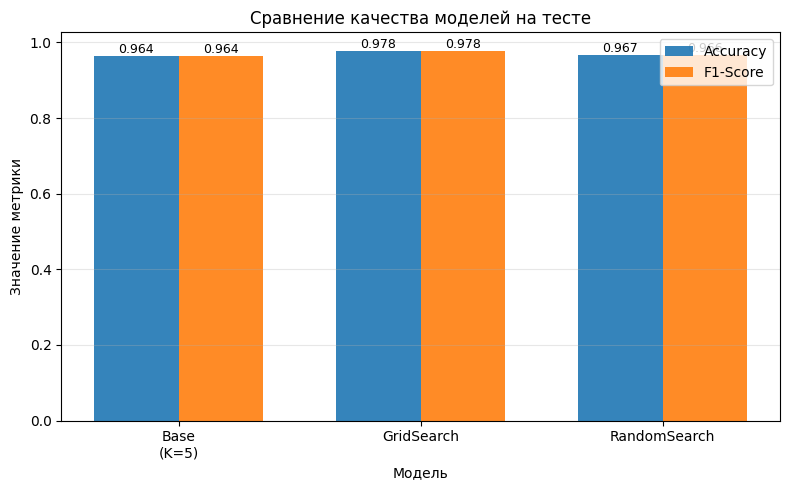

In [29]:
import matplotlib.pyplot as plt

# Данные для графика
models = ['Base\n(K=5)', 'GridSearch', 'RandomSearch']
accuracy = [0.9644, 0.9778, 0.9667]
f1 = [0.9643, 0.9777, 0.9664]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', alpha=0.9)
bars2 = ax.bar(x + width/2, f1, width, label='F1-Score', alpha=0.9)

ax.set_xlabel('Модель')
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение качества моделей на тесте')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Подписи значений на столбцах
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()